In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import cv2
from PIL import Image
import os, random

import tensorflow as tf
import keras as ke
from keras.models import Sequential, Model
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization

import sklearn.metrics as skm
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.utils import class_weight

In [5]:
%cd "drive//MyDrive/TCC-Lucas-Gambim-Guedes"
!ls -l

/content/drive/MyDrive/TCC-Lucas-Gambim-Guedes
total 13
drwx------ 2 root root 4096 Sep  6 23:20 arquivos
drwx------ 2 root root 4096 Aug 29 20:15 code-base
drwx------ 2 root root 4096 Sep  1 14:55 papers
-rw------- 1 root root  184 Dec  7 03:48 Projeto-tcc-lucas.gdoc


In [6]:
USDERMA_DATASET_PATH = "code-base/datasets/us-derma-kaggle/201database.csv"

df = pd.read_csv(USDERMA_DATASET_PATH)
df.head()

,images_bw,image_doppler,label,dx,freq;;;;;;
0,images/bw/01_bw.jpg,images/bw/01_doppler.jpg,BENIGN,VENOUS MALFORMATION,lowr;;;;;;VENOUS MALFROMATION
1,images/bw/02_bw.jpg,images/bw/02_doppler.jpg,BENIGN,LEIOMIOMA,lowr;;;;;;
2,images/bw/03_bw.jpg,images/bw/03_doppler.jpg,BENIGN,ANGIOMA,lowr;;;;;;
3,images/bw/04_bw.jpg,images/bw/04_doppler.jpg,BENIGN,SCHWANOMA,lowr;;;;;;
4,images/bw/05_bw.jpg,images/bw/05_doppler.jpg,BENIGN,LEIOMIOMA,lowr;;;;;;


In [7]:
def save_images_in_folder(df, folder_path, column_name):
    for i, row in df.iterrows():
        image_path = f"code-base/datasets/us-derma-kaggle/{row[column_name]}"
        if not os.path.exists(image_path):
            continue

        img = Image.open(image_path)
        img.save(os.path.join(folder_path, os.path.basename(image_path)))
    

In [8]:
benign_df = df[df[' label'] == ' BENIGN'] # filter the dataframe to get only benign samples
malignant_df = df[df[' label'] == ' MALIGNANT'] # filter the dataframe to get only malignant samples

# Create folders for benign and malignant images in the processed dataset if they don't exist
benign_folder_path = "code-base/datasets/us-derma-processed-v2/benigno" 
malignant_folder_path = "code-base/datasets/us-derma-processed-v2/maligno"

if not os.path.exists(benign_folder_path):
    os.makedirs(benign_folder_path)

if not os.path.exists(malignant_folder_path):
    os.makedirs(malignant_folder_path)

save_images_in_folder(benign_df, benign_folder_path, "images_bw") # save images in benign folder of the processed dataset
save_images_in_folder(malignant_df, malignant_folder_path, "images_bw") # save images in malignant folder of the processed dataset

In [9]:

image_dir = "code-base/datasets/us-derma-processed-v2/"

# Initializes two empty lists to store the paths to the images and their associated labels
image_paths = []
labels = []

# Identifies in the directories the paths to each of the images and their associated labels
for class_name in os.listdir(image_dir):
    class_path = os.path.join(image_dir, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            # Image paths
            img_path = os.path.join(class_path, img_name)
            image_paths.append(img_path)
            #Labels
            labels.append(class_name)

# Converts the Python list into a NumPy array
image_paths = np.array(image_paths)
labels = np.array(labels)


In [10]:
def pre_process_images(images_path, labels, target_size=(224, 224)):
    images = []
    for path in images_path:
        img = Image.open(path).convert('L')  # Convert to grayscale
        img = img.resize(target_size)  # Resize to target size
        img_array = np.array(img) / 255.0  # Normalize pixel values to [0, 1]
        images.append(img_array)

    labels = np.array([0 if label == 'benigno' else 1 for label in labels])  # Convert labels to binary (0 for benign, 1 for malignant)
    return np.array(images), np.array(labels)

In [11]:
image, labels = pre_process_images(image_paths, labels)

X_train, X_test, y_train, Y_test = train_test_split(image, labels, test_size=0.10, random_state=42, stratify=labels) # split the dataset into training and testing sets, with 20% of the data reserved for testing
X_train, X_val, y_train, Y_val = train_test_split(X_train, y_train, test_size=0.20, random_state=42, stratify=y_train) # further split the training set into training and validation sets, with 25% of the training data reserved for validation

## Model

In [12]:

random_seed = 42
np.random.seed(random_seed)
tf.random.set_seed(random_seed)
np.random.seed(random_seed)
random.seed(random_seed)


weights=class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)

## Model
model = Sequential()

model.add(Conv2D(16, kernel_size=(5, 5), activation='relu', input_shape=(224, 224, 1)))
model.add(MaxPooling2D(pool_size=(3, 3)))
model.add(Conv2D(32, kernel_size=(5, 5), activation='relu'))
model.add(MaxPooling2D(pool_size=(3, 3)))

model.add(Flatten())
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 220, 220, 16)   │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 73, 73, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 69, 69, 32)     │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16928)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │       169,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 182,549 (713.08 KB)

 Trainable params: 182,549 (713.08 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
opt = ke.optimizers.Adam( # Exponential decay learning rate schedule
    learning_rate= ke.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.00008,
        decay_steps= 15, #15
        decay_rate=0.85
    )
) #85

model.compile(optimizer=opt, metrics=["accuracy"], loss="binary_crossentropy")
history = model.fit(
    X_train, 
    y_train, 
    epochs=100, 
    batch_size=32,
    verbose=1,
    class_weight={0:weights[0], 1:weights[1]},
    validation_data=(X_val, Y_val)
)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 662ms/step - accuracy: 0.3412 - loss: 0.6996 - val_accuracy: 0.3143 - val_loss: 0.7042
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 626ms/step - accuracy: 0.3412 - loss: 0.6933 - val_accuracy: 0.4000 - val_loss: 0.6957
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 834ms/step - accuracy: 0.4263 - loss: 0.6901 - val_accuracy: 0.4857 - val_loss: 0.6915
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 625ms/step - accuracy: 0.5185 - loss: 0.6864 - val_accuracy: 0.4857 - val_loss: 0.6895
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 617ms/step - accuracy: 0.5702 - loss: 0.6819 - val_accuracy: 0.6000 - val_loss: 0.6855
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 799ms/step - accuracy: 0.6581 - loss: 0.6775 - val_accuracy: 0.7143 - val_loss: 0.6813
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 610ms/step - accuracy: 0.6968 - loss: 0.6731 - val_accuracy: 0.7143 - val_loss: 0.6775
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 635ms/step - accuracy: 0.7049 - loss: 0.6683 - val_accuracy: 0.6857 - v

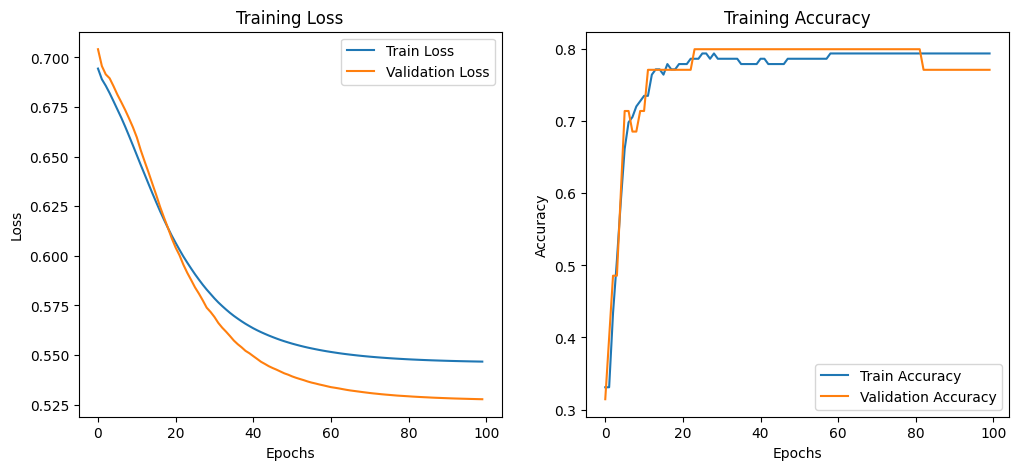

In [15]:
train_loss = history.history['loss']
train_acc = history.history['accuracy']
val_loss = history.history["val_loss"]
val_acc = history.history["val_accuracy"]


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [17]:
teste = model.predict(X_test)
teste = (teste > 0.5).astype(int).flatten()
print(classification_report(Y_test, teste, target_names=['benigno', 'maligno']))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
              precision    recall  f1-score   support

     benigno       0.80      0.92      0.86        13
     maligno       0.80      0.57      0.67         7

    accuracy                           0.80        20
   macro avg       0.80      0.75      0.76        20
weighted avg       0.80      0.80      0.79        20



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step


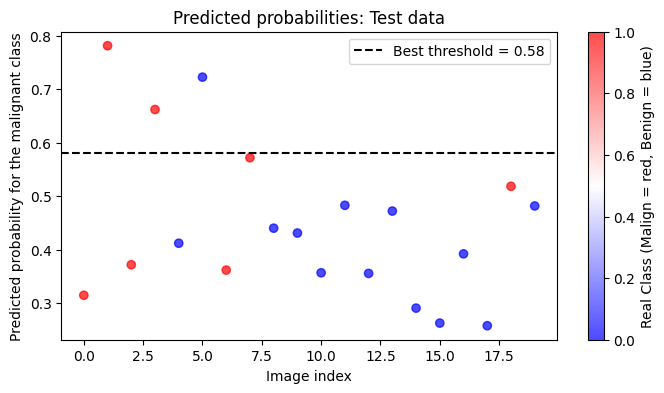

In [25]:
# scatter plot of teste vs Y_test
y_pred_prob = model.predict(X_test).flatten()  # Predicted probabilities
y_test = Y_test.flatten()  # Real class



plt.figure(figsize=(8, 4))
plt.scatter(range(len(y_pred_prob)), y_pred_prob, c=y_test, cmap="bwr", alpha=0.7)
plt.axhline(y=0.58, color='black', linestyle='--', label='Best threshold = 0.58')
plt.title("Predicted probabilities: Test data")
plt.xlabel("Image index")
plt.ylabel("Predicted probability for the malignant class")
plt.colorbar(label="Real Class (Malign = red, Benign = blue)")
plt.legend()
plt.show()
